In [1]:
"""You’ve been hired as a data consultant by an NGO working on SDG 4 (Quality Education) and SDG 10 (Reduced Inequalities). The
NGO supports a regional network of students, mentors, and educators. Your task is to use network analysis to identify:
• Who plays a central role in the network?
• Which nodes may be isolated or at risk of exclusion?
• Where connectivity improvements may be needed?"""

'You’ve been hired as a data consultant by an NGO working on SDG 4 (Quality Education) and SDG 10 (Reduced Inequalities). The\nNGO supports a regional network of students, mentors, and educators. Your task is to use network analysis to identify:\n• Who plays a central role in the network?\n• Which nodes may be isolated or at risk of exclusion?\n• Where connectivity improvements may be needed?'

In [6]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
# Load CSVs
nodes_df = pd.read_csv("week5_tutorial_nodes.csv")
edges_df = pd.read_csv("week5_tutorial_edges.csv")
# Create graph
G = nx.Graph()
for _, row in nodes_df.iterrows():
    G.add_node(row['name'], type=row['type'], gender=row['gender'], region=row['region'])
for _, row in edges_df.iterrows():
    G.add_edge(row['Source'], row['Target'], weight=row['Weight'])

print(nodes_df.head())
print(edges_df.head())

    name     type  gender region
0  Aisha  Student  Female  North
1    Ben  Student    Male  South
2  Chloe  Teacher  Female  North
3  David  Student    Male   East
4  Elena   Mentor  Female   West
  Source Target  Weight
0  Aisha  Chloe       5
1    Ben  Farid       3
2  Chloe  David       4
3  David  Elena       2
4  Elena  Grace       4


In [3]:
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Is the network connected?", nx.is_connected(G))
# Node degrees
for node in G.nodes():
    print(f"{node}: Degree = {G.degree(node)}")

Number of nodes: 8
Number of edges: 10
Is the network connected? True
Aisha: Degree = 2
Ben: Degree = 3
Chloe: Degree = 3
David: Degree = 2
Elena: Degree = 3
Farid: Degree = 2
Grace: Degree = 3
Hugo: Degree = 2


In [9]:
#Who is the most connected?
central_connector = nx.betweenness_centrality(G)
top_connector = max(central_connector, key=central_connector.get)
print(f"\nThe person that is the most connected is {top_connector}.")



The person that is the most connected is Elena.


In [11]:
#Who is the least connected?
least_connector = nx.betweenness_centrality(G)
least_connector = min(central_connector, key=central_connector.get)
print(f"\nThe person that is the least connected is {least_connector}.")



The person that is the least connected is Farid.


In [18]:
# Betweenness Centrality
centrality = nx.betweenness_centrality(G)
print("Betweenness Centrality:")
for k, v in sorted(centrality.items(), key=lambda x: x[1], reverse=True):
    print(f"{k}: {round(v, 3)}")
    
# Clustering Coefficient
clustering = nx.clustering(G)
print("\nClustering Coefficient:")
for k, v in sorted(clustering.items(), key=lambda x: x[1], reverse=True):
    print(f"{k}: {round(v, 2)}")

print("\nElena connects most of the different nodes in the network, makes sense as she is the mentor. While Farid has the least outer connections but is embedded in a clique.") 

Betweenness Centrality:
Elena: 0.294
Grace: 0.254
Chloe: 0.198
Ben: 0.175
Aisha: 0.159
David: 0.056
Hugo: 0.056
Farid: 0.0

Clustering Coefficient:
Farid: 1.0
Ben: 0.33
Grace: 0.33
Aisha: 0
Chloe: 0
David: 0
Elena: 0
Hugo: 0

Elena connects most of the different nodes in the network, makes sense as she is the mentor. While Farid has the least outer connections but is embedded in a clique.


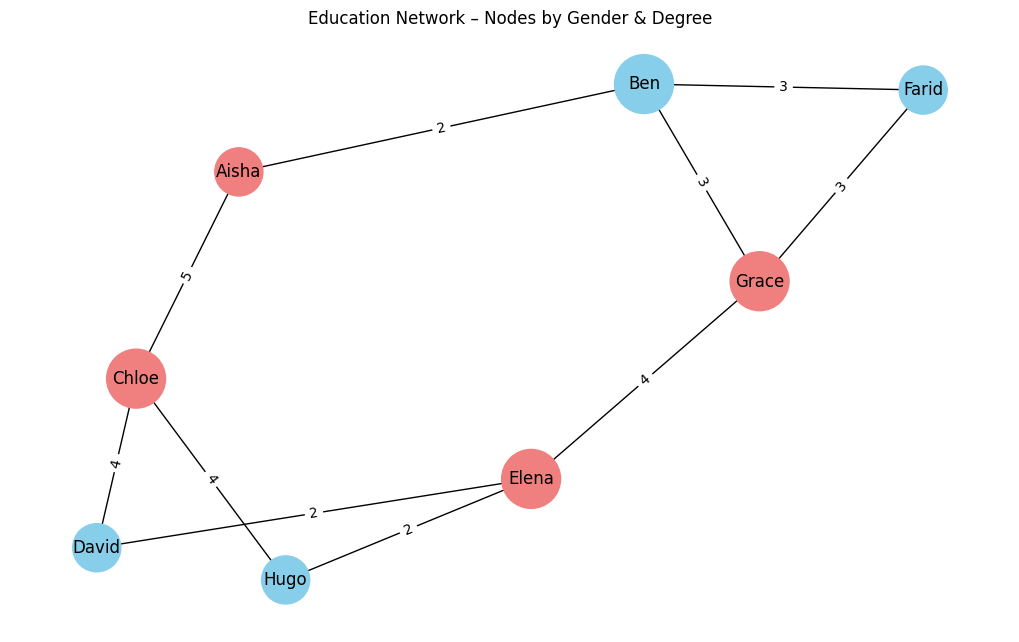

In [19]:
# Layout and attributes
pos = nx.spring_layout(G, seed=42)
gender_colors = {'Male': 'skyblue', 'Female': 'lightcoral'}
node_colors = [gender_colors[G.nodes[n]['gender']] for n in G.nodes]
node_sizes = [G.degree(n) * 600 for n in G.nodes]
plt.figure(figsize=(10, 6))
nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=node_sizes)
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, 'weight'))
plt.title("Education Network – Nodes by Gender & Degree")
plt.show()

After removal, is connected? True


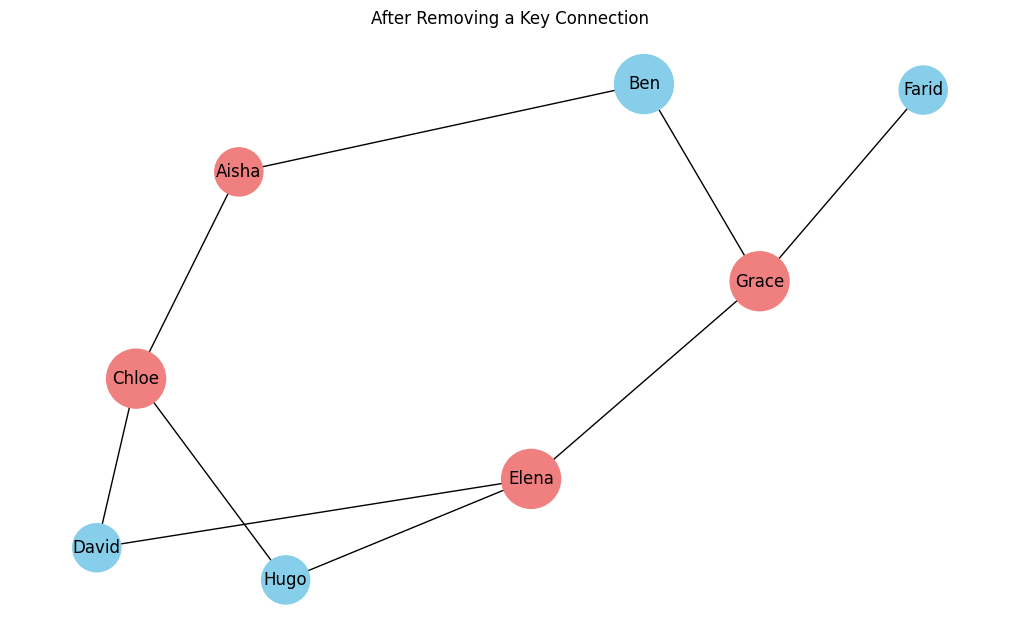

In [20]:
# Try disconnecting a node
G.remove_edge("Ben", "Farid")
print("After removal, is connected?", nx.is_connected(G))
# Re-plot the updated graph
plt.figure(figsize=(10, 6))
nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=node_sizes)
plt.title("After Removing a Key Connection")
plt.show()

In [44]:
#Adding new mentor node
G.add_nodes_from(["Cameron", "Farid"])
G.nodes["Cameron"]["gender"] = "Male"
G.nodes["Cameron"]["type"] = "Mentor"
G.nodes["Cameron"]["region"] = "North"
#Verifying Cameron is added
print(G.nodes())

['Aisha', 'Ben', 'Chloe', 'David', 'Elena', 'Farid', 'Grace', 'Hugo', 'Cameron']


In [45]:
G.remove_nodes_from(["B", "e", "n"])
#Verifying nodes are fixed 
print(G.nodes())

['Aisha', 'Ben', 'Chloe', 'David', 'Elena', 'Farid', 'Grace', 'Hugo', 'Cameron']


In [46]:
#Adding new edges from Cameron to Ben and Farid
G.add_edges_from([("Cameron", "Ben"), 
                  ("Cameron", "Farid")])

In [47]:
#Verifying new edges
print(G.edges())

[('Aisha', 'Chloe'), ('Aisha', 'Ben'), ('Ben', 'Grace'), ('Ben', 'Cameron'), ('Chloe', 'David'), ('Chloe', 'Hugo'), ('David', 'Elena'), ('Elena', 'Grace'), ('Elena', 'Hugo'), ('Farid', 'Grace'), ('Farid', 'Cameron')]


In [48]:
#Adding new weights to each edge
G.add_weighted_edges_from([("Aisha", "Chloe", 10),
                           ("Aisha", "Ben", 4),
                           ("Ben", "Grace", 6),
                           ("Ben", "Cameron", 8),
                           ("Chloe", "David", 8),
                           ("Chloe", "Hugo", 8),
                           ("David", "Elena", 4),
                           ("Elena", "Grace", 8),
                           ("Elena", "Hugo", 4),
                           ("Farid", "Grace", 6),
                           ("Farid", "Cameron", 10)])

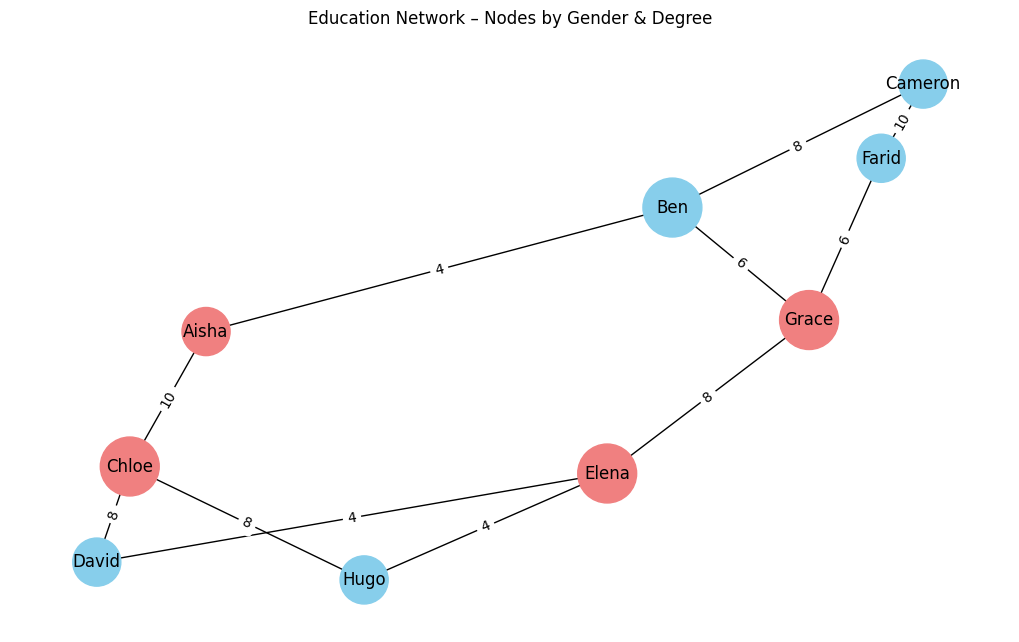

In [49]:
#Redrawing graph
pos = nx.spring_layout(G, seed=42)
gender_colors = {'Male': 'skyblue', 'Female': 'lightcoral'}
node_colors = [gender_colors[G.nodes[n]['gender']] for n in G.nodes]
node_sizes = [G.degree(n) * 600 for n in G.nodes]

plt.figure(figsize=(10, 6))
nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=node_sizes)
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, 'weight'))
plt.title("Education Network – Nodes by Gender & Degree")
plt.show()

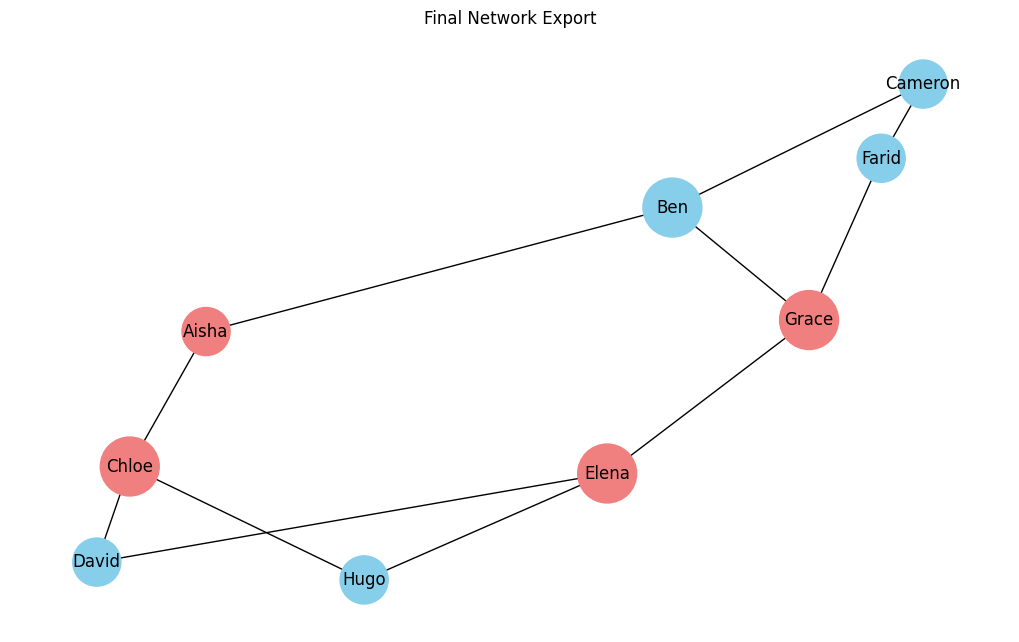

In [51]:
plt.figure(figsize=(10,6))
nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=node_sizes)
plt.title("Final Network Export")
plt.savefig("week5_network_final.png")
plt.show()